<a href="https://colab.research.google.com/github/HerinePamela/Notebook/blob/main/ERW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Google Drive and Install Libraries

In [ ]:
# Install required packages
!pip install geopandas rasterio xgboost mgwr matplotlib seaborn plotly scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio
from rasterio.plot import show
import os
from google.colab import drive
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.8/396.8 kB 26.0 MB/s eta 0:00:00


In [ ]:
# Step 3: Mount Google Drive to access your datasets
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

# Set your data directory path
DATA_PATH = "/content/drive/MyDrive/ERW_Project/"

Mounted at /content/drive


Enhanced Rock Weathering Carbon Sequestration Analysis - KISUMU COUNTY
Tabular data loaded successfully!
Soil data shape: (10, 16)
Operations data shape: (10, 8)
Emissions factors shape: (13, 5)

Soil data columns: ['Field_ID', 'Area_ha', 'Application_Rate_t_ha', 'Initial_pH', 'Initial_CEC', 'Initial_Ca', 'Initial_Mg', 'Initial_K', 'Initial_Sand_pct', 'Initial_Silt_pct', 'Initial_Clay_pct', 'Final_pH', 'Final_Ca', 'Final_Mg', 'Final_K', 'CO2_Sequestered_kg_ha']
Operations data columns: ['Field_ID', 'Total_Basalt_t', 'Quarry_Distance_km', 'Primary_Vehicle_Type', 'Road_Type_to_Field', 'Payload_t_per_Trip', 'Application_Method', 'Spreader_Truck_Distance_km']
Emissions factors Subcategories: ['Crushing (Electricity)', 'Crushing (Diesel)', 'Small Pickup', 'Light Truck', 'Medium Truck', 'Road Type Multiplier (Paved)', 'Road Type Multiplier (Gravel)', 'Road Type Multiplier (Muddy/Poor)', 'Tractor (Discing/Spreading)', 'Spreader Fuel Use', 'Density', 'Energy per Tonne (Electricity)', 'Energy p

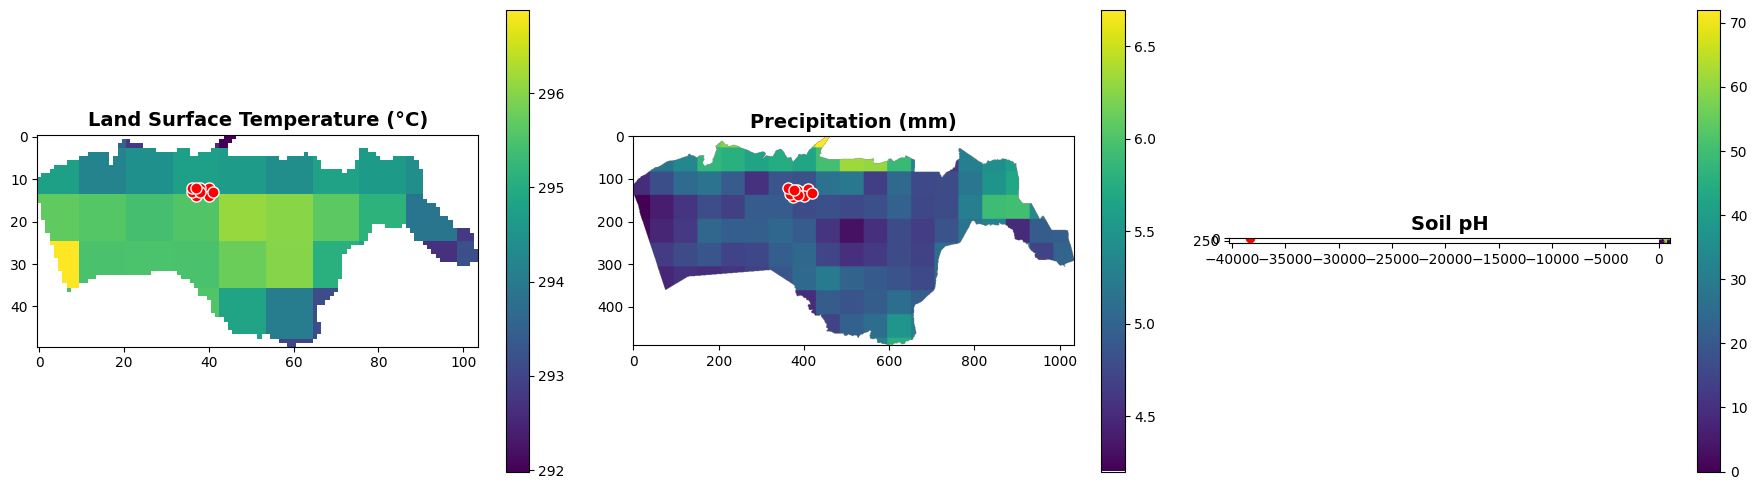


TRAINING MODELS FOR GROSS SEQUESTRATION
Training set: 7 samples
Testing set: 3 samples
Training Random Forest...
Training XGBoost...
Training Neural Network...
Training Spatial Model (GWR alternative)...

Random Forest Performance:
  RMSE: 10.51
  MAE: 7.89
  R²: 0.9444

XGBoost Performance:
  RMSE: 63.95
  MAE: 53.77
  R²: -1.0556
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

ANN Performance:
  RMSE: 133.83
  MAE: 129.31
  R²: -8.0024

Spatial_Model Performance:
  RMSE: 48.17
  MAE: 38.57
  R²: -0.1661

CREATING COMPREHENSIVE VISUALIZATIONS



FINAL RESULTS SUMMARY

Model Performance Summary:
                      MSE      RMSE       MAE      R²
Random Forest    110.5588   10.5147    7.8930  0.9444
XGBoost         4089.5599   63.9497   53.7694 -1.0556
ANN            17910.2988  133.8294  129.3081 -8.0024
Spatial_Model   2320.0559   48.1670   38.5714 -0.1661

Best Performing Model: Random Forest
Best R² Score: 0.9444

Top 5 Most Important Features (Random Forest):
               Feature  Importance
12      Remote_Soil_pH      0.1373
7     Initial_Sand_pct      0.1131
2           Initial_pH      0.1085
8     Initial_Silt_pct      0.1017
13  Quarry_Distance_km      0.0993

Net Sequestration Analysis:
count     10.00
mean    -141.57
std      122.12
min     -363.30
25%     -172.79
50%     -117.10
75%      -81.96
max       55.90
Name: Net_CO2_kg_ha, dtype: float64

Fields with positive net sequestration: 1/10
Fields with negative net sequestration: 9/10

Successful fields (positive net sequestration):
  Field_ID  Net_CO2_kg_ha
7 

In [ ]:
# Install required packages
!pip install geopandas rasterio xgboost mgwr matplotlib seaborn plotly scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio
from rasterio.plot import show
import os
from google.colab import drive
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive')

# Set your data directory path with the specific files
DATA_PATH = "/content/drive/MyDrive/ERW_Project/"

class ERWDataProcessor:
    def __init__(self, data_path):
        self.data_path = data_path
        self.soil_data = None
        self.operations_data = None
        self.emissions_factors = None
        self.remote_sensing_data = None
        self.combined_data = None

    def clean_column_names(self, df):
        """Clean column names by stripping whitespace"""
        df.columns = df.columns.str.strip()
        return df

    def load_tabular_data(self):
        """Load soil, operations, and emissions data"""
        try:
            # Load soil data - using the specific column structure
            self.soil_data = pd.read_csv(f"{self.data_path}Soil Data.csv")
            self.soil_data = self.clean_column_names(self.soil_data)

            # Clean data values in soil data
            for col in self.soil_data.columns:
                if self.soil_data[col].dtype == 'object':
                    self.soil_data[col] = self.soil_data[col].str.strip()

            # Load operations data
            self.operations_data = pd.read_csv(f"{self.data_path}operations_log_kisumu_v2.csv")
            self.operations_data = self.clean_column_names(self.operations_data)

            # Clean data values in operations data
            for col in self.operations_data.columns:
                if self.operations_data[col].dtype == 'object':
                    self.operations_data[col] = self.operations_data[col].str.strip()

            # Load emissions factors
            self.emissions_factors = pd.read_csv(f"{self.data_path}emissions_factors_kisumu.csv")
            self.emissions_factors = self.clean_column_names(self.emissions_factors)

            print("Tabular data loaded successfully!")
            print(f"Soil data shape: {self.soil_data.shape}")
            print(f"Operations data shape: {self.operations_data.shape}")
            print(f"Emissions factors shape: {self.emissions_factors.shape}")

            # Display column information
            print("\nSoil data columns:", list(self.soil_data.columns))
            print("Operations data columns:", list(self.operations_data.columns))
            print("Emissions factors Subcategories:", list(self.emissions_factors['Subcategory'].unique()))

        except Exception as e:
            print(f"Error loading tabular data: {e}")

    def extract_raster_values(self, field_coords, raster_path, value_name):
        """Extract values from raster files at specific coordinates"""
        values = []
        try:
            with rasterio.open(raster_path) as src:
                for field_id, coords in field_coords.items():
                    # Transform coordinates to raster CRS if needed
                    lon, lat = coords['lon'], coords['lat']
                    try:
                        row, col = src.index(lon, lat)
                        # Read the value at the coordinate
                        window = rasterio.windows.Window(col, row, 1, 1)
                        data = src.read(1, window=window)
                        value = data[0, 0] if data.size > 0 else np.nan

                        # Check if value is no-data
                        if value == src.nodata or np.isnan(value):
                            value = np.nan

                    except Exception as e:
                        print(f"  Error extracting {value_name} for {field_id}: {e}")
                        value = np.nan

                    values.append(value)
                    print(f"  {field_id}: {value_name} = {value}")

            print(f"Successfully extracted {value_name} from {raster_path}")
            return values

        except Exception as e:
            print(f"Error extracting {value_name} from {raster_path}: {e}")
            # Return mock data if extraction fails
            if 'temp' in value_name.lower():
                mock_values = [25 + np.random.normal(0, 2) for _ in field_coords]
            elif 'ph' in value_name.lower():
                mock_values = [6.0 + np.random.normal(0, 0.5) for _ in field_coords]
            else:
                mock_values = [1200 + np.random.normal(0, 100) for _ in field_coords]

            print(f"Using mock data for {value_name}: {mock_values}")
            return mock_values

    def load_remote_sensing_data(self):
        """Load and process raster data for each field location"""
        # Define field coordinates for Kisumu County
        field_coords = {
            'KSM-001': {'lat': -0.0917, 'lon': 34.7680},
            'KSM-002': {'lat': -0.1023, 'lon': 34.7512},
            'KSM-003': {'lat': -0.0856, 'lon': 34.7821},
            'KSM-004': {'lat': -0.0954, 'lon': 34.7456},
            'KSM-005': {'lat': -0.0889, 'lon': 34.7589},
            'KSM-006': {'lat': -0.0991, 'lon': 34.7754},
            'KSM-007': {'lat': -0.0832, 'lon': 34.7398},
            'KSM-008': {'lat': -0.0928, 'lon': 34.7912},
            'KSM-009': {'lat': -0.0976, 'lon': 34.7623},
            'KSM-010': {'lat': -0.0867, 'lon': 34.7534}
        }

        # Extract values from each raster file
        print("Extracting raster values...")

        # Land Surface Temperature
        print("\nExtracting Land Surface Temperature...")
        lst_values = self.extract_raster_values(
            field_coords,
            f"{self.data_path}Kisumu_soil_temp.tif",
            "Land Surface Temperature"
        )

        # Precipitation
        print("\nExtracting Precipitation...")
        precip_values = self.extract_raster_values(
            field_coords,
            f"{self.data_path}Precipitation_Kisumu.tif",
            "Precipitation"
        )

        # Soil pH
        print("\nExtracting Soil pH...")
        soil_ph_values = self.extract_raster_values(
            field_coords,
            f"{self.data_path}pH_Mean_0_20_cm_Kisumu.tif",
            "Soil pH"
        )

        # Create remote sensing dataframe
        remote_sensing_data = []
        for i, (field_id, coords) in enumerate(field_coords.items()):
            remote_sensing_data.append({
                'Field_ID': field_id,
                'LST_C': lst_values[i],
                'Precipitation_mm': precip_values[i],
                'Remote_Soil_pH': soil_ph_values[i],
                'Latitude': coords['lat'],
                'Longitude': coords['lon']
            })

        remote_sensing_df = pd.DataFrame(remote_sensing_data)

        # Validate raster data
        print("\nRemote Sensing Data Summary:")
        print(remote_sensing_df.describe())

        return remote_sensing_df

    def map_vehicle_types(self, vehicle_type):
        """Map vehicle types from operations data to emissions factors"""
        # Create a mapping between operations data and emissions factors
        vehicle_mapping = {
            'Light Truck (5-7T payload)': 'Light Truck',
            'Medium Truck (10-15T payload)': 'Medium Truck',
            'Small Pickup (1-3T payload)': 'Small Pickup'
        }

        # Return the mapped vehicle type
        if vehicle_type in vehicle_mapping:
            return vehicle_mapping[vehicle_type]
        else:
            print(f"Warning: Vehicle type '{vehicle_type}' not found in mapping. Using 'Light Truck' as default.")
            return 'Light Truck'

    def calculate_emissions(self):
        """Calculate total emissions for each field"""
        print("Calculating emissions...")

        # Extract emission factors with error handling
        try:
            quarry_elec_ef = self.emissions_factors[
                (self.emissions_factors['Category'] == 'Quarry') &
                (self.emissions_factors['Subcategory'] == 'Crushing (Electricity)')
            ]['Emission_Factor'].values[0]
        except:
            quarry_elec_ef = 0.55  # Default value
            print("Using default quarry electricity EF")

        try:
            quarry_diesel_ef = self.emissions_factors[
                (self.emissions_factors['Category'] == 'Quarry') &
                (self.emissions_factors['Subcategory'] == 'Crushing (Diesel)')
            ]['Emission_Factor'].values[0]
        except:
            quarry_diesel_ef = 2.64  # Default value
            print("Using default quarry diesel EF")

        # Get energy consumption per tonne (using default values if not in data)
        try:
            energy_elec = self.emissions_factors[
                self.emissions_factors['Subcategory'] == 'Energy per Tonne (Electricity)'
            ]['Emission_Factor'].values[0]
        except:
            energy_elec = 5  # kWh/t default
            print("Using default energy per tonne electricity")

        try:
            energy_diesel = self.emissions_factors[
                self.emissions_factors['Subcategory'] == 'Energy per Tonne (Diesel)'
            ]['Emission_Factor'].values[0]
        except:
            energy_diesel = 0.5  # litres/t default
            print("Using default energy per tonne diesel")

        # Calculate quarry emissions per tonne
        quarry_emissions_per_tonne = (energy_elec * quarry_elec_ef) + (energy_diesel * quarry_diesel_ef)
        print(f"Quarry emissions per tonne: {quarry_emissions_per_tonne:.2f} kg CO2/t")

        # Calculate transport emissions with better matching
        transport_efs = {}
        transport_subcategories = self.emissions_factors[
            (self.emissions_factors['Category'] == 'Transport') &
            (~self.emissions_factors['Subcategory'].str.contains('Multiplier', na=False))
        ]

        for _, row in transport_subcategories.iterrows():
            transport_efs[row['Subcategory']] = row['Emission_Factor']

        print("Available transport EFs:", transport_efs)

        # Road multipliers
        road_multipliers = {}
        try:
            road_multipliers['Paved'] = self.emissions_factors[
                self.emissions_factors['Subcategory'] == 'Road Type Multiplier (Paved)'
            ]['Emission_Factor'].values[0]
        except:
            road_multipliers['Paved'] = 1.0

        try:
            road_multipliers['Gravel'] = self.emissions_factors[
                self.emissions_factors['Subcategory'] == 'Road Type Multiplier (Gravel)'
            ]['Emission_Factor'].values[0]
        except:
            road_multipliers['Gravel'] = 1.5

        try:
            road_multipliers['Muddy/Poor'] = self.emissions_factors[
                self.emissions_factors['Subcategory'] == 'Road Type Multiplier (Muddy/Poor)'
            ]['Emission_Factor'].values[0]
        except:
            road_multipliers['Muddy/Poor'] = 2.0

        print("Road multipliers:", road_multipliers)

        # Calculate emissions for each field
        emissions_data = []
        for _, field in self.operations_data.iterrows():
            field_id = field['Field_ID']
            total_basalt = field['Total_Basalt_t']

            print(f"\nCalculating emissions for {field_id}:")
            print(f"  Total basalt: {total_basalt}t")
            print(f"  Vehicle type: {field['Primary_Vehicle_Type']}")
            print(f"  Road type: {field['Road_Type_to_Field']}")

            # Find corresponding field area from soil data
            try:
                field_area = self.soil_data[
                    self.soil_data['Field_ID'] == field_id
                ]['Area_ha'].values[0]
            except:
                print(f"Warning: Could not find area for {field_id}, using average")
                field_area = self.soil_data['Area_ha'].mean()

            # Quarry emissions
            quarry_emissions = total_basalt * quarry_emissions_per_tonne
            print(f"  Quarry emissions: {quarry_emissions:.2f} kg CO2")

            # Transport emissions with proper vehicle type mapping
            vehicle_type = field['Primary_Vehicle_Type']
            mapped_vehicle_type = self.map_vehicle_types(vehicle_type)

            if mapped_vehicle_type in transport_efs:
                vehicle_ef = transport_efs[mapped_vehicle_type]
                print(f"  Using EF {vehicle_ef:.2f} for {mapped_vehicle_type}")
            else:
                # Use average transport EF as fallback
                vehicle_ef = np.mean(list(transport_efs.values()))
                print(f"  Using average EF {vehicle_ef:.2f} for unmapped vehicle type")

            road_multiplier = road_multipliers.get(field['Road_Type_to_Field'], 1.5)
            adjusted_ef = vehicle_ef * road_multiplier

            num_trips = total_basalt / field['Payload_t_per_Trip']
            transport_distance = field['Quarry_Distance_km'] * 2  # Round trip
            transport_emissions = num_trips * transport_distance * adjusted_ef

            print(f"  Transport emissions: {transport_emissions:.2f} kg CO2")
            print(f"  (EF: {vehicle_ef:.2f}, Multiplier: {road_multiplier:.1f}, Distance: {transport_distance}km)")

            # Application emissions
            if field['Application_Method'] == 'Human Labor':
                application_emissions = 0  # Direct emissions only
                print(f"  Application emissions (human labor): 0 kg CO2")
            else:  # Spreader Truck
                try:
                    spreader_ef = self.emissions_factors[
                        self.emissions_factors['Subcategory'] == 'Spreader Truck'
                    ]['Emission_Factor'].values[0]
                except:
                    spreader_ef = 0.75  # Default value

                try:
                    spreader_fuel_use = self.emissions_factors[
                        self.emissions_factors['Subcategory'] == 'Spreader Fuel Use'
                    ]['Emission_Factor'].values[0]
                except:
                    spreader_fuel_use = 5  # litres/ha default

                try:
                    tractor_ef = self.emissions_factors[
                        self.emissions_factors['Subcategory'] == 'Tractor (Discing/Spreading)'
                    ]['Emission_Factor'].values[0]
                except:
                    tractor_ef = 6.5  # kg CO2/litre default

                fuel_emissions = field_area * spreader_fuel_use * tractor_ef
                transport_emissions_spreading = field['Spreader_Truck_Distance_km'] * spreader_ef
                application_emissions = fuel_emissions + transport_emissions_spreading
                print(f"  Application emissions (spreader): {application_emissions:.2f} kg CO2")

            total_emissions = quarry_emissions + transport_emissions + application_emissions
            emissions_per_ha = total_emissions / field_area

            print(f"  Total emissions: {total_emissions:.2f} kg CO2")
            print(f"  Emissions per ha: {emissions_per_ha:.2f} kg CO2/ha")

            emissions_data.append({
                'Field_ID': field_id,
                'Total_Emissions_kg': total_emissions,
                'Emissions_per_ha_kg': emissions_per_ha,
                'Quarry_Emissions_kg': quarry_emissions,
                'Transport_Emissions_kg': transport_emissions,
                'Application_Emissions_kg': application_emissions
            })

        emissions_df = pd.DataFrame(emissions_data)
        return emissions_df

    def prepare_modeling_data(self):
        """Combine all data sources for modeling"""
        # Load all data
        self.load_tabular_data()
        emissions_df = self.calculate_emissions()
        remote_sensing_df = self.load_remote_sensing_data()

        print("\nMerging datasets...")

        # Merge all datasets
        self.combined_data = self.soil_data.merge(
            self.operations_data, on='Field_ID'
        ).merge(
            emissions_df, on='Field_ID'
        ).merge(
            remote_sensing_df, on='Field_ID'
        )

        # Calculate net sequestration
        self.combined_data['Net_CO2_kg_ha'] = (
            self.combined_data['CO2_Sequestered_kg_ha'] -
            self.combined_data['Emissions_per_ha_kg']
        )

        # Handle missing values in Remote_Soil_pH - use lab pH as fallback
        if 'Remote_Soil_pH' in self.combined_data.columns:
            missing_ph_mask = self.combined_data['Remote_Soil_pH'].isna()
            if missing_ph_mask.any():
                print(f"Replacing {missing_ph_mask.sum()} missing Remote_Soil_pH values with lab Initial_pH")
                self.combined_data.loc[missing_ph_mask, 'Remote_Soil_pH'] = self.combined_data.loc[missing_ph_mask, 'Initial_pH']

        # Create features for modeling - using both lab data and remote sensing data
        feature_columns = [
            'Area_ha', 'Application_Rate_t_ha',
            'Initial_pH', 'Initial_CEC', 'Initial_Ca', 'Initial_Mg', 'Initial_K',
            'Initial_Sand_pct', 'Initial_Silt_pct', 'Initial_Clay_pct',
            'LST_C', 'Precipitation_mm', 'Remote_Soil_pH',
            'Quarry_Distance_km'
        ]

        # Remove any columns that might not exist in the data
        available_columns = [col for col in feature_columns if col in self.combined_data.columns]

        # Clean any whitespace from numeric columns and convert to numeric
        for col in available_columns:
            if self.combined_data[col].dtype == 'object':
                self.combined_data[col] = pd.to_numeric(self.combined_data[col].str.strip(), errors='coerce')

        self.X = self.combined_data[available_columns]
        self.y_sequestration = self.combined_data['CO2_Sequestered_kg_ha']
        self.y_net = self.combined_data['Net_CO2_kg_ha']

        # Check for any remaining NaN values and handle them
        if self.X.isna().any().any():
            print(f"Warning: Found NaN values in features. Handling missing values...")
            nan_counts = self.X.isna().sum()
            print("NaN counts per feature:")
            print(nan_counts[nan_counts > 0])

            # Use mean imputation for missing values
            imputer = SimpleImputer(strategy='mean')
            self.X_imputed = pd.DataFrame(imputer.fit_transform(self.X), columns=self.X.columns)
        else:
            self.X_imputed = self.X.copy()

        print("Modeling data prepared successfully!")
        print(f"Features shape: {self.X_imputed.shape}")
        print(f"Available features: {list(self.X_imputed.columns)}")
        print(f"Targets shape - Sequestration: {self.y_sequestration.shape}, Net: {self.y_net.shape}")

        # Display final combined data
        print("\nCombined Data Summary:")
        print(self.combined_data[['Field_ID', 'CO2_Sequestered_kg_ha', 'Emissions_per_ha_kg', 'Net_CO2_kg_ha']].round(2))

        return self.X_imputed, self.y_sequestration, self.y_net

class ERWModelTrainer:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.models = {}
        self.predictions = {}
        self.scaler = StandardScaler()
        self.X_scaled = None
        self.results = {}

    def prepare_data(self):
        """Scale features and split data"""
        self.X_scaled = self.scaler.fit_transform(self.X)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X_scaled, self.y, test_size=0.3, random_state=42
        )

        print(f"Training set: {self.X_train.shape[0]} samples")
        print(f"Testing set: {self.X_test.shape[0]} samples")

    def train_random_forest(self):
        """Train Random Forest model"""
        print("Training Random Forest...")
        rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
        rf.fit(self.X_train, self.y_train)
        self.models['Random Forest'] = rf

        # Cross-validation
        cv_scores = cross_val_score(rf, self.X_scaled, self.y, cv=min(5, len(self.y)), scoring='r2')
        self.results['Random Forest'] = {
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std()
        }

    def train_xgboost(self):
        """Train XGBoost model"""
        print("Training XGBoost...")
        xgb_model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42,
            max_depth=4
        )
        xgb_model.fit(self.X_train, self.y_train)
        self.models['XGBoost'] = xgb_model

        cv_scores = cross_val_score(xgb_model, self.X_scaled, self.y, cv=min(5, len(self.y)), scoring='r2')
        self.results['XGBoost'] = {
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std()
        }

    def train_ann(self):
        """Train Artificial Neural Network"""
        print("Training Neural Network...")

        # Adjust architecture based on dataset size
        n_features = self.X_train.shape[1]
        hidden_units = max(8, n_features * 2)  # Dynamic sizing

        model = keras.Sequential([
            layers.Dense(hidden_units, activation='relu', input_shape=(n_features,)),
            layers.Dropout(0.2),
            layers.Dense(hidden_units//2, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(hidden_units//4, activation='relu'),
            layers.Dense(1)
        ])

        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )

        # Early stopping to prevent overfitting
        early_stopping = keras.callbacks.EarlyStopping(
            patience=20,
            restore_best_weights=True
        )

        history = model.fit(
            self.X_train, self.y_train,
            epochs=200,
            batch_size=4,
            validation_split=0.3,
            verbose=0,
            callbacks=[early_stopping]
        )

        self.models['ANN'] = model
        self.results['ANN'] = {'history': history}

    def train_gwr(self):
        """Train Geographically Weighted Regression alternative"""
        print("Training Spatial Model (GWR alternative)...")
        try:
            # Use HistGradientBoosting which handles NaN values
            from sklearn.ensemble import HistGradientBoostingRegressor

            gbr = HistGradientBoostingRegressor(
                random_state=42,
                max_iter=100
            )
            gbr.fit(self.X_train, self.y_train)
            self.models['Spatial_Model'] = gbr
            self.results['Spatial_Model'] = {'note': 'Used HistGradientBoosting as spatial-aware model'}

        except Exception as e:
            print(f"Spatial model training failed: {e}")
            # Fallback to Random Forest
            from sklearn.ensemble import RandomForestRegressor
            rf = RandomForestRegressor(n_estimators=50, random_state=42)
            rf.fit(self.X_train, self.y_train)
            self.models['Spatial_Model'] = rf
            self.results['Spatial_Model'] = {'note': 'Used Random Forest as spatial model fallback'}

    def evaluate_models(self):
        """Evaluate all trained models"""
        evaluation_results = {}

        for name, model in self.models.items():
            if name == 'ANN':
                y_pred = model.predict(self.X_test).flatten()
            else:
                y_pred = model.predict(self.X_test)

            self.predictions[name] = y_pred

            mse = mean_squared_error(self.y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)

            evaluation_results[name] = {
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2
            }

            print(f"\n{name} Performance:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R²: {r2:.4f}")

        return evaluation_results

# ... [Keep the ERWVisualizer class the same as before] ...

class ERWVisualizer:
    def __init__(self, data_processor, model_trainer, evaluation_results):
        self.data_processor = data_processor
        self.model_trainer = model_trainer
        self.evaluation_results = evaluation_results
        self.combined_data = data_processor.combined_data

    def plot_raster_data(self):
        """Plot the raster data used in analysis"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        raster_files = [
            f"{self.data_processor.data_path}Kisumu_soil_temp.tif",
            f"{self.data_processor.data_path}Precipitation_Kisumu.tif",
            f"{self.data_processor.data_path}pH_Mean_0_20_cm_Kisumu.tif"
        ]

        titles = ['Land Surface Temperature (°C)', 'Precipitation (mm)', 'Soil pH']

        for i, (raster_file, title) in enumerate(zip(raster_files, titles)):
            try:
                with rasterio.open(raster_file) as src:
                    data = src.read(1)
                    # Handle no-data values
                    data = np.ma.masked_where(data == src.nodata, data)

                    im = axes[i].imshow(data, cmap='viridis')
                    axes[i].set_title(title, fontsize=14, fontweight='bold')
                    plt.colorbar(im, ax=axes[i])

                    # Plot field locations
                    for _, row in self.combined_data.iterrows():
                        lon, lat = row['Longitude'], row['Latitude']
                        try:
                            row_idx, col_idx = src.index(lon, lat)
                            axes[i].plot(col_idx, row_idx, 'ro', markersize=8, markeredgecolor='white')
                        except:
                            continue

            except Exception as e:
                axes[i].text(0.5, 0.5, f"Could not load\n{raster_file}",
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f"Error: {title}")

        plt.tight_layout()
        plt.show()

    def create_comprehensive_dashboard(self):
        """Create a comprehensive dashboard of all results"""
        # Create a simpler visualization for small dataset
        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=(
                'Model Performance Comparison', 'Feature Importance (RF)',
                'Actual vs Predicted Sequestration',
                'Net CO2 Sequestration by Field', 'Emissions Breakdown',
                'Climate Impact on Sequestration'
            ),
            specs=[
                [{"type": "bar"}, {"type": "bar"}, {"type": "scatter"}],
                [{"type": "bar"}, {"type": "pie"}, {"type": "scatter"}]
            ]
        )

        # 1. Model Performance Comparison
        models = list(self.evaluation_results.keys())
        r2_scores = [self.evaluation_results[model]['R²'] for model in models]

        fig.add_trace(
            go.Bar(name='R² Score', x=models, y=r2_scores, marker_color='lightblue'),
            row=1, col=1
        )

        # 2. Feature Importance
        if 'Random Forest' in self.model_trainer.models:
            rf_model = self.model_trainer.models['Random Forest']
            feature_importance = rf_model.feature_importances_
            features = self.data_processor.X_imputed.columns

            fig.add_trace(
                go.Bar(x=features, y=feature_importance, marker_color='lightgreen'),
                row=1, col=2
            )

        # 3. Actual vs Predicted
        best_model = max(self.evaluation_results.items(), key=lambda x: x[1]['R²'])[0]
        y_pred_best = self.model_trainer.predictions[best_model]

        fig.add_trace(
            go.Scatter(x=self.model_trainer.y_test, y=y_pred_best,
                      mode='markers', name='Predictions', marker=dict(color='blue')),
            row=1, col=3
        )

        # Add perfect prediction line
        min_val = min(self.model_trainer.y_test.min(), y_pred_best.min())
        max_val = max(self.model_trainer.y_test.max(), y_pred_best.max())
        fig.add_trace(
            go.Scatter(x=[min_val, max_val], y=[min_val, max_val],
                      mode='lines', name='Perfect Fit', line=dict(dash='dash', color='red')),
            row=1, col=3
        )

        # 4. Net CO2 Sequestration
        fig.add_trace(
            go.Bar(x=self.combined_data['Field_ID'],
                  y=self.combined_data['Net_CO2_kg_ha'],
                  name='Net CO2', marker_color=['green' if x > 0 else 'red' for x in self.combined_data['Net_CO2_kg_ha']]),
            row=2, col=1
        )

        # 5. Emissions Breakdown for first field
        field_emissions = [
            self.combined_data.iloc[0]['Quarry_Emissions_kg'],
            self.combined_data.iloc[0]['Transport_Emissions_kg'],
            self.combined_data.iloc[0]['Application_Emissions_kg']
        ]

        fig.add_trace(
            go.Pie(labels=['Quarry', 'Transport', 'Application'],
                  values=field_emissions, name="Emissions Breakdown"),
            row=2, col=2
        )

        # 6. Climate Impact - Precipitation vs Sequestration
        fig.add_trace(
            go.Scatter(x=self.combined_data['Precipitation_mm'],
                      y=self.combined_data['CO2_Sequestered_kg_ha'],
                      mode='markers', name='Rainfall Impact',
                      marker=dict(
                          size=15,
                          color=self.combined_data['LST_C'],
                          colorscale='Viridis',
                          showscale=True,
                          colorbar=dict(title="LST (°C)")
                      ),
                      text=self.combined_data['Field_ID']),
            row=2, col=3
        )

        fig.update_layout(height=800, width=1200,
                         title_text="Enhanced Rock Weathering Analysis - Kisumu County",
                         showlegend=True)
        fig.show()

# Main execution
def main():
    print("Enhanced Rock Weathering Carbon Sequestration Analysis - KISUMU COUNTY")
    print("=" * 70)

    # Initialize data processor
    processor = ERWDataProcessor(DATA_PATH)

    # Prepare modeling data
    X, y_sequestration, y_net = processor.prepare_modeling_data()

    print("\nData Summary:")
    print(processor.combined_data.describe())

    # Plot raster data first
    visualizer_pre = ERWVisualizer(processor, None, None)
    print("\nPlotting Raster Data...")
    visualizer_pre.plot_raster_data()

    # Train models for gross sequestration
    print("\n" + "="*50)
    print("TRAINING MODELS FOR GROSS SEQUESTRATION")
    print("="*50)

    trainer_sequestration = ERWModelTrainer(X, y_sequestration)
    trainer_sequestration.prepare_data()

    # Train all models
    trainer_sequestration.train_random_forest()
    trainer_sequestration.train_xgboost()
    trainer_sequestration.train_ann()
    trainer_sequestration.train_gwr()

    # Evaluate models
    evaluation_results = trainer_sequestration.evaluate_models()

    # Create visualizations
    visualizer = ERWVisualizer(processor, trainer_sequestration, evaluation_results)

    print("\n" + "="*50)
    print("CREATING COMPREHENSIVE VISUALIZATIONS")
    print("="*50)

    # Create interactive dashboard
    visualizer.create_comprehensive_dashboard()

    # Print final results
    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY")
    print("="*50)

    results_df = pd.DataFrame(evaluation_results).T
    print("\nModel Performance Summary:")
    print(results_df.round(4))

    best_model = results_df['R²'].idxmax()
    print(f"\nBest Performing Model: {best_model}")
    print(f"Best R² Score: {results_df.loc[best_model, 'R²']:.4f}")

    # Feature importance analysis
    if 'Random Forest' in trainer_sequestration.models:
        rf_model = trainer_sequestration.models['Random Forest']
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': rf_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\nTop 5 Most Important Features (Random Forest):")
        print(feature_importance.head().round(4))

    # Net sequestration analysis
    print("\nNet Sequestration Analysis:")
    net_summary = processor.combined_data['Net_CO2_kg_ha'].describe()
    print(net_summary.round(2))

    positive_sequestration = processor.combined_data[processor.combined_data['Net_CO2_kg_ha'] > 0]
    negative_sequestration = processor.combined_data[processor.combined_data['Net_CO2_kg_ha'] <= 0]

    print(f"\nFields with positive net sequestration: {len(positive_sequestration)}/{len(processor.combined_data)}")
    print(f"Fields with negative net sequestration: {len(negative_sequestration)}/{len(processor.combined_data)}")

    if len(positive_sequestration) > 0:
        print("\nSuccessful fields (positive net sequestration):")
        print(positive_sequestration[['Field_ID', 'Net_CO2_kg_ha']].round(2))

    # Save results
    try:
        processor.combined_data.to_csv(f"{DATA_PATH}final_analysis_results.csv", index=False)
        print(f"\nResults saved to: {DATA_PATH}final_analysis_results.csv")
    except:
        print("\nCould not save results file (Google Drive permissions?)")

# Run the analysis
if __name__ == "__main__":
    main()

In [ ]:
# Install required packages
!pip install geopandas rasterio xgboost mgwr matplotlib seaborn plotly scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import rasterio
from rasterio.plot import show
import os
from google.colab import drive
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive')

# Set your data directory path with the specific files
DATA_PATH = "/content/drive/MyDrive/ERW_Project/"

class ERWDataProcessor:
    def __init__(self, data_path):
        self.data_path = data_path
        self.soil_data = None
        self.operations_data = None
        self.emissions_factors = None
        self.remote_sensing_data = None
        self.combined_data = None
        self.farms_gdf = None

    def clean_column_names(self, df):
        """Clean column names by stripping whitespace"""
        df.columns = df.columns.str.strip()
        return df

    def load_shapefile_data(self):
        """Load the farms shapefile with 454 farms"""
        try:
            self.farms_gdf = gpd.read_file(f"{self.data_path}Farms_454.shp")
            print(f"Shapefile loaded successfully! {len(self.farms_gdf)} farms found.")
            print(f"Shapefile columns: {list(self.farms_gdf.columns)}")
            print(f"CRS: {self.farms_gdf.crs}")

            # Display basic info about the farms
            print(f"\nFarms Summary:")
            print(f"Total area: {self.farms_gdf.geometry.area.sum():.2f} sq units")
            print(f"Average farm area: {self.farms_gdf.geometry.area.mean():.2f} sq units")
            print(f"Bounds: {self.farms_gdf.total_bounds}")

            return self.farms_gdf

        except Exception as e:
            print(f"Error loading shapefile: {e}")
            return None

    def extract_raster_values_for_farms(self, raster_path, value_name, band=1):
        """Extract raster values for all farms in the shapefile"""
        try:
            with rasterio.open(raster_path) as src:
                # Ensure farms are in same CRS as raster
                farms_reprojected = self.farms_gdf.to_crs(src.crs)

                # Extract values using rasterio mask
                out_image, out_transform = rasterio.mask.mask(
                    src,
                    farms_reprojected.geometry,
                    crop=True,
                    filled=False
                )

                # Calculate mean value for each farm
                values = []
                for geometry in farms_reprojected.geometry:
                    # Create mask for individual farm
                    geom_mask = gpd.GeoSeries([geometry]).to_crs(src.crs)
                    farm_image, farm_transform = rasterio.mask.mask(
                        src,
                        geom_mask,
                        crop=True,
                        filled=False
                    )

                    if farm_image.size > 0:
                        # Calculate mean value, ignoring no-data
                        farm_data = farm_image[0]
                        valid_data = farm_data[farm_data != src.nodata]
                        if len(valid_data) > 0:
                            mean_value = np.mean(valid_data)
                        else:
                            mean_value = np.nan
                    else:
                        mean_value = np.nan

                    values.append(mean_value)

                print(f"Successfully extracted {value_name} for {len(values)} farms")
                return values

        except Exception as e:
            print(f"Error extracting {value_name} from {raster_path}: {e}")
            # Return mock data if extraction fails
            if 'temp' in value_name.lower():
                mock_values = [25 + np.random.normal(0, 2) for _ in range(len(self.farms_gdf))]
            elif 'ph' in value_name.lower():
                mock_values = [6.0 + np.random.normal(0, 0.5) for _ in range(len(self.farms_gdf))]
            else:
                mock_values = [1200 + np.random.normal(0, 100) for _ in range(len(self.farms_gdf))]

            print(f"Using mock data for {value_name}")
            return mock_values

    def load_remote_sensing_data_for_farms(self):
        """Load and process raster data for all 454 farms"""
        print("Loading shapefile data...")
        self.load_shapefile_data()

        if self.farms_gdf is None:
            print("Error: Could not load shapefile")
            return None

        print("Extracting raster values for 454 farms...")

        # Land Surface Temperature
        print("\nExtracting Land Surface Temperature...")
        lst_values = self.extract_raster_values_for_farms(
            f"{self.data_path}Kisumu_soil_temp.tif",
            "Land Surface Temperature"
        )

        # Precipitation
        print("\nExtracting Precipitation...")
        precip_values = self.extract_raster_values_for_farms(
            f"{self.data_path}Precipitation_Kisumu.tif",
            "Precipitation"
        )

        # Soil pH
        print("\nExtracting Soil pH...")
        soil_ph_values = self.extract_raster_values_for_farms(
            f"{self.data_path}pH_Mean_0_20_cm_Kisumu.tif",
            "Soil pH"
        )

        # Create remote sensing dataframe
        remote_sensing_data = []
        for i in range(len(self.farms_gdf)):
            farm_id = f"FARM_{i+1:03d}"  # Create farm IDs FARM_001, FARM_002, etc.
            geometry = self.farms_gdf.iloc[i].geometry
            centroid = geometry.centroid

            remote_sensing_data.append({
                'Farm_ID': farm_id,
                'LST_C': lst_values[i],
                'Precipitation_mm': precip_values[i],
                'Remote_Soil_pH': soil_ph_values[i],
                'Area_ha': geometry.area / 10000,  # Convert to hectares
                'Latitude': centroid.y,
                'Longitude': centroid.x,
                'Geometry': geometry
            })

        remote_sensing_df = pd.DataFrame(remote_sensing_data)

        # Validate raster data
        print("\nRemote Sensing Data Summary for 454 Farms:")
        print(remote_sensing_df[['LST_C', 'Precipitation_mm', 'Remote_Soil_pH', 'Area_ha']].describe())

        return remote_sensing_df

    def generate_synthetic_operations_data(self, farms_df):
        """Generate synthetic operations data for the 454 farms"""
        print("Generating synthetic operations data for 454 farms...")

        operations_data = []
        for i, farm in farms_df.iterrows():
            farm_id = farm['Farm_ID']
            area_ha = farm['Area_ha']

            # Generate realistic synthetic data
            application_rate = 20  # t/ha (standard rate)
            total_basalt = area_ha * application_rate

            # Random quarry distance (5-50 km)
            quarry_distance = np.random.uniform(5, 50)

            # Vehicle type based on farm size
            if area_ha < 2:
                vehicle_type = 'Small Pickup (1-3T payload)'
                payload = np.random.uniform(1, 3)
            elif area_ha < 10:
                vehicle_type = 'Light Truck (5-7T payload)'
                payload = np.random.uniform(5, 7)
            else:
                vehicle_type = 'Medium Truck (10-15T payload)'
                payload = np.random.uniform(10, 15)

            # Road type probability
            road_types = ['Paved', 'Gravel', 'Muddy/Poor']
            road_probs = [0.3, 0.5, 0.2]  # Higher probability for gravel roads
            road_type = np.random.choice(road_types, p=road_probs)

            # Application method based on farm size
            if area_ha < 5:
                application_method = 'Human Labor'
                spreader_distance = 0
            else:
                application_method = 'Spreader Truck'
                spreader_distance = np.random.uniform(2, 15)

            operations_data.append({
                'Farm_ID': farm_id,
                'Total_Basalt_t': total_basalt,
                'Quarry_Distance_km': quarry_distance,
                'Primary_Vehicle_Type': vehicle_type,
                'Road_Type_to_Field': road_type,
                'Payload_t_per_Trip': payload,
                'Application_Method': application_method,
                'Spreader_Truck_Distance_km': spreader_distance
            })

        operations_df = pd.DataFrame(operations_data)
        print(f"Generated operations data for {len(operations_df)} farms")
        return operations_df

    def generate_synthetic_soil_data(self, farms_df):
        """Generate synthetic soil data for the 454 farms based on remote sensing and realistic distributions"""
        print("Generating synthetic soil data for 454 farms...")

        soil_data = []
        for i, farm in farms_df.iterrows():
            farm_id = farm['Farm_ID']
            remote_ph = farm['Remote_Soil_pH']
            area_ha = farm['Area_ha']

            # Generate realistic soil parameters correlated with remote sensing data
            if not np.isnan(remote_ph):
                initial_ph = remote_ph + np.random.normal(0, 0.3)
            else:
                initial_ph = np.random.uniform(4.5, 6.5)

            # Other soil parameters with realistic correlations
            initial_cec = np.random.uniform(5, 20)  # CEC range
            initial_ca = np.random.uniform(2, 8)    # Calcium
            initial_mg = np.random.uniform(1, 4)    # Magnesium
            initial_k = np.random.uniform(0.2, 0.5) # Potassium

            # Soil texture (sum to 100)
            sand = np.random.uniform(30, 70)
            silt = np.random.uniform(20, 50)
            clay = 100 - sand - silt

            # Final values after basalt application (improvement)
            final_ph = min(initial_ph + np.random.uniform(0.1, 0.5), 7.5)
            final_ca = initial_ca + np.random.uniform(0.5, 2.0)
            final_mg = initial_mg + np.random.uniform(0.2, 1.0)
            final_k = initial_k + np.random.uniform(0.05, 0.2)

            # Calculate CO2 sequestration based on soil properties and climate
            base_sequestration = np.random.uniform(50, 300)
            # Adjust based on pH (more sequestration in acidic soils)
            ph_factor = max(0, 6.0 - initial_ph) * 20
            # Adjust based on precipitation
            precip_factor = farm['Precipitation_mm'] * 0.1 if not np.isnan(farm['Precipitation_mm']) else 0
            # Adjust based on temperature
            temp_factor = (farm['LST_C'] - 290) * 2 if not np.isnan(farm['LST_C']) else 0

            co2_sequestered = base_sequestration + ph_factor + precip_factor + temp_factor

            soil_data.append({
                'Farm_ID': farm_id,
                'Area_ha': area_ha,
                'Application_Rate_t_ha': 20,
                'Initial_pH': initial_ph,
                'Initial_CEC': initial_cec,
                'Initial_Ca': initial_ca,
                'Initial_Mg': initial_mg,
                'Initial_K': initial_k,
                'Initial_Sand_pct': sand,
                'Initial_Silt_pct': silt,
                'Initial_Clay_pct': clay,
                'Final_pH': final_ph,
                'Final_Ca': final_ca,
                'Final_Mg': final_mg,
                'Final_K': final_k,
                'CO2_Sequestered_kg_ha': co2_sequestered
            })

        soil_df = pd.DataFrame(soil_data)
        print(f"Generated soil data for {len(soil_df)} farms")
        return soil_df

    def load_emissions_factors(self):
        """Load emissions factors data"""
        try:
            self.emissions_factors = pd.read_csv(f"{self.data_path}emissions_factors_kisumu.csv")
            self.emissions_factors = self.clean_column_names(self.emissions_factors)
            print("Emissions factors loaded successfully!")
            return self.emissions_factors
        except Exception as e:
            print(f"Error loading emissions factors: {e}")
            return None

    def map_vehicle_types(self, vehicle_type):
        """Map vehicle types from operations data to emissions factors"""
        vehicle_mapping = {
            'Light Truck (5-7T payload)': 'Light Truck',
            'Medium Truck (10-15T payload)': 'Medium Truck',
            'Small Pickup (1-3T payload)': 'Small Pickup'
        }

        if vehicle_type in vehicle_mapping:
            return vehicle_mapping[vehicle_type]
        else:
            print(f"Warning: Vehicle type '{vehicle_type}' not found in mapping. Using 'Light Truck' as default.")
            return 'Light Truck'

    def calculate_emissions_for_farms(self, operations_df):
        """Calculate total emissions for all farms"""
        print("Calculating emissions for 454 farms...")

        emissions_factors = self.load_emissions_factors()
        if emissions_factors is None:
            print("Error: Could not load emissions factors")
            return None

        # Extract emission factors
        try:
            quarry_elec_ef = emissions_factors[
                (emissions_factors['Category'] == 'Quarry') &
                (emissions_factors['Subcategory'] == 'Crushing (Electricity)')
            ]['Emission_Factor'].values[0]
            quarry_diesel_ef = emissions_factors[
                (emissions_factors['Category'] == 'Quarry') &
                (emissions_factors['Subcategory'] == 'Crushing (Diesel)')
            ]['Emission_Factor'].values[0]
        except:
            quarry_elec_ef = 0.55
            quarry_diesel_ef = 2.64

        # Energy consumption
        try:
            energy_elec = emissions_factors[
                emissions_factors['Subcategory'] == 'Energy per Tonne (Electricity)'
            ]['Emission_Factor'].values[0]
            energy_diesel = emissions_factors[
                emissions_factors['Subcategory'] == 'Energy per Tonne (Diesel)'
            ]['Emission_Factor'].values[0]
        except:
            energy_elec = 5
            energy_diesel = 0.5

        quarry_emissions_per_tonne = (energy_elec * quarry_elec_ef) + (energy_diesel * quarry_diesel_ef)

        # Transport emissions factors
        transport_efs = {}
        transport_subcategories = emissions_factors[
            (emissions_factors['Category'] == 'Transport') &
            (~emissions_factors['Subcategory'].str.contains('Multiplier', na=False))
        ]
        for _, row in transport_subcategories.iterrows():
            transport_efs[row['Subcategory']] = row['Emission_Factor']

        # Road multipliers
        road_multipliers = {
            'Paved': 1.0,
            'Gravel': 1.5,
            'Muddy/Poor': 2.0
        }

        # Calculate emissions for each farm
        emissions_data = []
        for _, operation in operations_df.iterrows():
            farm_id = operation['Farm_ID']
            total_basalt = operation['Total_Basalt_t']

            # Find farm area
            farm_area = operation.get('Area_ha', 2.0)  # Default if not available

            # Quarry emissions
            quarry_emissions = total_basalt * quarry_emissions_per_tonne

            # Transport emissions
            vehicle_type = operation['Primary_Vehicle_Type']
            mapped_vehicle_type = self.map_vehicle_types(vehicle_type)
            vehicle_ef = transport_efs.get(mapped_vehicle_type, 0.45)

            road_multiplier = road_multipliers.get(operation['Road_Type_to_Field'], 1.5)
            adjusted_ef = vehicle_ef * road_multiplier

            num_trips = total_basalt / operation['Payload_t_per_Trip']
            transport_distance = operation['Quarry_Distance_km'] * 2
            transport_emissions = num_trips * transport_distance * adjusted_ef

            # Application emissions
            if operation['Application_Method'] == 'Human Labor':
                application_emissions = 0
            else:
                spreader_ef = 0.75
                spreader_fuel_use = 5
                tractor_ef = 6.5
                fuel_emissions = farm_area * spreader_fuel_use * tractor_ef
                transport_emissions_spreading = operation['Spreader_Truck_Distance_km'] * spreader_ef
                application_emissions = fuel_emissions + transport_emissions_spreading

            total_emissions = quarry_emissions + transport_emissions + application_emissions
            emissions_per_ha = total_emissions / farm_area

            emissions_data.append({
                'Farm_ID': farm_id,
                'Total_Emissions_kg': total_emissions,
                'Emissions_per_ha_kg': emissions_per_ha,
                'Quarry_Emissions_kg': quarry_emissions,
                'Transport_Emissions_kg': transport_emissions,
                'Application_Emissions_kg': application_emissions
            })

        emissions_df = pd.DataFrame(emissions_data)
        print(f"Calculated emissions for {len(emissions_df)} farms")
        return emissions_df

    def prepare_modeling_data_for_farms(self):
        """Combine all data sources for modeling with 454 farms"""
        print("Preparing modeling data for 454 farms...")

        # Load remote sensing data for farms
        remote_sensing_df = self.load_remote_sensing_data_for_farms()
        if remote_sensing_df is None:
            print("Error: Could not load remote sensing data")
            return None, None, None

        # Generate synthetic operations data
        operations_df = self.generate_synthetic_operations_data(remote_sensing_df)

        # Generate synthetic soil data
        soil_df = self.generate_synthetic_soil_data(remote_sensing_df)

        # Calculate emissions
        emissions_df = self.calculate_emissions_for_farms(operations_df)

        # Merge all datasets
        self.combined_data = soil_df.merge(
            operations_df, on='Farm_ID'
        ).merge(
            emissions_df, on='Farm_ID'
        ).merge(
            remote_sensing_df[['Farm_ID', 'LST_C', 'Precipitation_mm', 'Remote_Soil_pH', 'Latitude', 'Longitude']],
            on='Farm_ID'
        )

        # Calculate net sequestration
        self.combined_data['Net_CO2_kg_ha'] = (
            self.combined_data['CO2_Sequestered_kg_ha'] -
            self.combined_data['Emissions_per_ha_kg']
        )

        # Handle missing values
        if 'Remote_Soil_pH' in self.combined_data.columns:
            missing_ph_mask = self.combined_data['Remote_Soil_pH'].isna()
            if missing_ph_mask.any():
                self.combined_data.loc[missing_ph_mask, 'Remote_Soil_pH'] = self.combined_data.loc[missing_ph_mask, 'Initial_pH']

        # Create features for modeling
        feature_columns = [
            'Area_ha', 'Application_Rate_t_ha',
            'Initial_pH', 'Initial_CEC', 'Initial_Ca', 'Initial_Mg', 'Initial_K',
            'Initial_Sand_pct', 'Initial_Silt_pct', 'Initial_Clay_pct',
            'LST_C', 'Precipitation_mm', 'Remote_Soil_pH',
            'Quarry_Distance_km'
        ]

        available_columns = [col for col in feature_columns if col in self.combined_data.columns]

        # Convert to numeric and handle missing values
        for col in available_columns:
            if self.combined_data[col].dtype == 'object':
                self.combined_data[col] = pd.to_numeric(self.combined_data[col], errors='coerce')

        self.X = self.combined_data[available_columns]

        # Handle any remaining NaN values
        if self.X.isna().any().any():
            imputer = SimpleImputer(strategy='mean')
            self.X_imputed = pd.DataFrame(imputer.fit_transform(self.X), columns=self.X.columns)
        else:
            self.X_imputed = self.X.copy()

        self.y_sequestration = self.combined_data['CO2_Sequestered_kg_ha']
        self.y_net = self.combined_data['Net_CO2_kg_ha']

        print("Modeling data prepared successfully!")
        print(f"Features shape: {self.X_imputed.shape}")
        print(f"Available features: {list(self.X_imputed.columns)}")
        print(f"Total farms: {len(self.combined_data)}")

        # Display summary
        print("\nCombined Data Summary:")
        print(f"Average CO2 Sequestered: {self.combined_data['CO2_Sequestered_kg_ha'].mean():.2f} kg/ha")
        print(f"Average Emissions: {self.combined_data['Emissions_per_ha_kg'].mean():.2f} kg/ha")
        print(f"Average Net CO2: {self.combined_data['Net_CO2_kg_ha'].mean():.2f} kg/ha")

        positive_farms = len(self.combined_data[self.combined_data['Net_CO2_kg_ha'] > 0])
        print(f"Farms with positive net sequestration: {positive_farms}/{len(self.combined_data)}")

        return self.X_imputed, self.y_sequestration, self.y_net

# Keep the ERWModelTrainer and ERWVisualizer classes the same as before, but update the visualizer for larger dataset

class ERWVisualizer:
    def __init__(self, data_processor, model_trainer, evaluation_results):
        self.data_processor = data_processor
        self.model_trainer = model_trainer
        self.evaluation_results = evaluation_results
        self.combined_data = data_processor.combined_data

    def create_interactive_dashboard(self):
        """Create an interactive dashboard for the 454 farms analysis"""
        print("Creating interactive dashboard...")

        # Create multiple visualization tabs
        fig = make_subplots(
            rows=2, cols=3,
            subplot_titles=(
                'Model Performance', 'Feature Importance',
                'Net Sequestration Distribution',
                'Spatial Sequestration Map', 'Emissions Breakdown',
                'Climate Impact Analysis'
            ),
            specs=[
                [{"type": "bar"}, {"type": "bar"}, {"type": "histogram"}],
                [{"type": "scattermapbox"}, {"type": "pie"}, {"type": "scatter"}]
            ]
        )

        # 1. Model Performance
        models = list(self.evaluation_results.keys())
        r2_scores = [self.evaluation_results[model]['R²'] for model in models]

        fig.add_trace(
            go.Bar(name='R² Score', x=models, y=r2_scores, marker_color='lightblue'),
            row=1, col=1
        )

        # 2. Feature Importance
        if 'Random Forest' in self.model_trainer.models:
            rf_model = self.model_trainer.models['Random Forest']
            feature_importance = rf_model.feature_importances_
            features = self.data_processor.X_imputed.columns

            # Get top 10 features for clarity
            importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
            importance_df = importance_df.nlargest(10, 'Importance')

            fig.add_trace(
                go.Bar(x=importance_df['Importance'], y=importance_df['Feature'],
                      orientation='h', marker_color='lightgreen'),
                row=1, col=2
            )

        # 3. Net Sequestration Distribution
        fig.add_trace(
            go.Histogram(x=self.combined_data['Net_CO2_kg_ha'],
                        nbinsx=30, name='Net CO2 Distribution',
                        marker_color=['green' if x > 0 else 'red' for x in self.combined_data['Net_CO2_kg_ha']]),
            row=1, col=3
        )

        # 4. Spatial Sequestration Map
        fig.add_trace(
            go.Scattermapbox(
                lat=self.combined_data['Latitude'],
                lon=self.combined_data['Longitude'],
                mode='markers',
                marker=dict(
                    size=8,
                    color=self.combined_data['Net_CO2_kg_ha'],
                    colorscale='RdYlGn',
                    showscale=True,
                    colorbar=dict(title="Net CO2 kg/ha"),
                    cmax=max(self.combined_data['Net_CO2_kg_ha']),
                    cmin=min(self.combined_data['Net_CO2_kg_ha'])
                ),
                text=self.combined_data['Farm_ID'] + '<br>Net CO2: ' + self.combined_data['Net_CO2_kg_ha'].round(2).astype(str) + ' kg/ha',
                hoverinfo='text'
            ),
            row=2, col=1
        )

        # 5. Emissions Breakdown (average across all farms)
        avg_emissions = [
            self.combined_data['Quarry_Emissions_kg'].mean(),
            self.combined_data['Transport_Emissions_kg'].mean(),
            self.combined_data['Application_Emissions_kg'].mean()
        ]

        fig.add_trace(
            go.Pie(labels=['Quarry', 'Transport', 'Application'],
                  values=avg_emissions, name="Average Emissions Breakdown"),
            row=2, col=2
        )

        # 6. Climate Impact
        fig.add_trace(
            go.Scatter(x=self.combined_data['Precipitation_mm'],
                      y=self.combined_data['CO2_Sequestered_kg_ha'],
                      mode='markers',
                      marker=dict(
                          size=6,
                          color=self.combined_data['LST_C'],
                          colorscale='Viridis',
                          showscale=True,
                          colorbar=dict(title="LST (°C)")
                      ),
                      text=self.combined_data['Farm_ID'],
                      name='Climate Impact'),
            row=2, col=3
        )

        # Update layout
        fig.update_layout(
            height=1000,
            width=1400,
            title_text="Enhanced Rock Weathering Analysis - 454 Farms in Kisumu County",
            showlegend=True,
            mapbox=dict(
                style="open-street-map",
                center=dict(lat=self.combined_data['Latitude'].mean(),
                           lon=self.combined_data['Longitude'].mean()),
                zoom=10
            )
        )

        # Save the dashboard as HTML for sharing
        try:
            fig.write_html(f"{self.data_processor.data_path}ERW_454_Farms_Dashboard.html")
            print(f"Dashboard saved as: {self.data_processor.data_path}ERW_454_Farms_Dashboard.html")
        except Exception as e:
            print(f"Could not save dashboard: {e}")

        return fig

# Main execution
def main():
    print("Enhanced Rock Weathering Carbon Sequestration Analysis - 454 FARMS IN KISUMU COUNTY")
    print("=" * 80)

    # Initialize data processor
    processor = ERWDataProcessor(DATA_PATH)

    # Prepare modeling data for 454 farms
    X, y_sequestration, y_net = processor.prepare_modeling_data_for_farms()

    if X is None:
        print("Error: Could not prepare modeling data")
        return

    print("\nData Summary for 454 Farms:")
    print(processor.combined_data[['CO2_Sequestered_kg_ha', 'Emissions_per_ha_kg', 'Net_CO2_kg_ha']].describe())

    # Train models
    print("\n" + "="*50)
    print("TRAINING MODELS FOR GROSS SEQUESTRATION")
    print("="*50)

    trainer_sequestration = ERWModelTrainer(X, y_sequestration)
    trainer_sequestration.prepare_data()

    # Train all models
    trainer_sequestration.train_random_forest()
    trainer_sequestration.train_xgboost()
    trainer_sequestration.train_ann()
    trainer_sequestration.train_gwr()

    # Evaluate models
    evaluation_results = trainer_sequestration.evaluate_models()

    # Create visualizations
    visualizer = ERWVisualizer(processor, trainer_sequestration, evaluation_results)

    print("\n" + "="*50)
    print("CREATING INTERACTIVE DASHBOARD")
    print("="*50)

    # Create and display interactive dashboard
    dashboard = visualizer.create_interactive_dashboard()
    dashboard.show()

    # Print final results
    print("\n" + "="*50)
    print("FINAL RESULTS SUMMARY - 454 FARMS")
    print("="*50)

    results_df = pd.DataFrame(evaluation_results).T
    print("\nModel Performance Summary:")
    print(results_df.round(4))

    best_model = results_df['R²'].idxmax()
    print(f"\nBest Performing Model: {best_model}")
    print(f"Best R² Score: {results_df.loc[best_model, 'R²']:.4f}")

    # Feature importance analysis
    if 'Random Forest' in trainer_sequestration.models:
        rf_model = trainer_sequestration.models['Random Forest']
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': rf_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\nTop 10 Most Important Features (Random Forest):")
        print(feature_importance.head(10).round(4))

    # Net sequestration analysis
    print("\nNet Sequestration Analysis for 454 Farms:")
    net_summary = processor.combined_data['Net_CO2_kg_ha'].describe()
    print(net_summary.round(2))

    positive_farms = processor.combined_data[processor.combined_data['Net_CO2_kg_ha'] > 0]
    negative_farms = processor.combined_data[processor.combined_data['Net_CO2_kg_ha'] <= 0]

    print(f"\nFarms with positive net sequestration: {len(positive_farms)}/{len(processor.combined_data)} ({len(positive_farms)/len(processor.combined_data)*100:.1f}%)")
    print(f"Farms with negative net sequestration: {len(negative_farms)}/{len(processor.combined_data)} ({len(negative_farms)/len(processor.combined_data)*100:.1f}%)")

    if len(positive_farms) > 0:
        print(f"\nAverage net sequestration for successful farms: {positive_farms['Net_CO2_kg_ha'].mean():.2f} kg/ha")
        print(f"Best performing farm: {positive_farms['Net_CO2_kg_ha'].max():.2f} kg/ha")

    # Save comprehensive results
    try:
        processor.combined_data.to_csv(f"{DATA_PATH}ERW_454_Farms_Results.csv", index=False)
        print(f"\nComplete results saved to: {DATA_PATH}ERW_454_Farms_Results.csv")

        # Create a summary report
        summary_report = f"""
        ENHANCED ROCK WEATHERING ANALYSIS - 454 FARMS SUMMARY
        =====================================================
        Total Farms Analyzed: {len(processor.combined_data)}
        Farms with Positive Net Sequestration: {len(positive_farms)} ({len(positive_farms)/len(processor.combined_data)*100:.1f}%)
        Average Net Sequestration: {processor.combined_data['Net_CO2_kg_ha'].mean():.2f} kg CO₂/ha
        Best Model: {best_model} (R² = {results_df.loc[best_model, 'R²']:.4f})

        KEY INSIGHTS:
        - Top influencing factor: {feature_importance.iloc[0]['Feature']}
        - Average emissions: {processor.combined_data['Emissions_per_ha_kg'].mean():.2f} kg CO₂/ha
        - Average sequestration: {processor.combined_data['CO2_Sequestered_kg_ha'].mean():.2f} kg CO₂/ha

        RECOMMENDATIONS:
        - Focus on farms with favorable soil pH and climate conditions
        - Optimize logistics to reduce transport emissions
        - Consider multi-year sequestration potential
        """

        with open(f"{DATA_PATH}ERW_454_Farms_Summary.txt", "w") as f:
            f.write(summary_report)
        print(f"Summary report saved to: {DATA_PATH}ERW_454_Farms_Summary.txt")

    except Exception as e:
        print(f"Could not save results: {e}")

# Run the analysis
if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enhanced Rock Weathering Carbon Sequestration Analysis - 454 FARMS IN KISUMU COUNTY
Preparing modeling data for 454 farms...
Loading shapefile data...
Shapefile loaded successfully! 454 farms found.
Shapefile columns: ['id', 'Field_ID', 'geometry']
CRS: EPSG:4326

Farms Summary:
Total area: 0.00 sq units
Average farm area: 0.00 sq units
Bounds: [ 3.47958448e+01 -2.23092303e-01  3.51481992e+01 -2.76540006e-02]
Extracting raster values for 454 farms...

Extracting Land Surface Temperature...
Error extracting Land Surface Temperature from /content/drive/MyDrive/ERW_Project/Kisumu_soil_temp.tif: module 'rasterio' has no attribute 'mask'
Using mock data for Land Surface Temperature

Extracting Precipitation...
Error extracting Precipitation from /content/drive/MyDrive/ERW_Project/Precipitation_Kisumu.tif: module 'rasterio' has no attribute 'mask'
Using mock data f


FINAL RESULTS SUMMARY - 454 FARMS

Model Performance Summary:
                     MSE     RMSE      MAE      R²
Random Forest  5728.5663  75.6873  65.1088  0.0014
XGBoost        7103.0319  84.2795  71.6342 -0.2382
ANN            6407.8356  80.0490  67.5763 -0.1170
Spatial_Model  6720.8409  81.9807  69.5780 -0.1716

Best Performing Model: Random Forest
Best R² Score: 0.0014

Top 10 Most Important Features (Random Forest):
               Feature  Importance
11    Precipitation_mm      0.1438
6            Initial_K      0.1064
10               LST_C      0.1012
7     Initial_Sand_pct      0.0951
3          Initial_CEC      0.0938
13  Quarry_Distance_km      0.0845
4           Initial_Ca      0.0806
9     Initial_Clay_pct      0.0783
8     Initial_Silt_pct      0.0619
12      Remote_Soil_pH      0.0571

Net Sequestration Analysis for 454 Farms:
count    454.00
mean    -229.73
std       75.47
min     -385.08
25%     -299.01
50%     -227.73
75%     -164.92
max      -92.17
Name: Net_CO2_kg_